# Notebook 5 — Análisis y KPIs

**Proyecto:** Portfolio Data Analyst — E-Commerce Analysis  
**Prerrequisito:** Notebook 4 ejecutada — esta notebook opera sobre el modelo relacional en `../data/model/`.  
**Entregable:** Análisis de las 11 hipótesis con KPIs documentados, validación cruzada Python vs SQL y dashboard de cierre.

---
## Índice
1. [Setup · carga del modelo · catálogo de KPIs](#1)
2. [H-01 · H-02 — Revenue y estacionalidad](#2)
3. [H-03 · H-04 · H-05 — Análisis de clientes](#3)
4. [H-06 · H-07 — Análisis de productos](#4)
5. [H-08 · H-09 — Análisis geográfico](#5)
6. [H-10 · H-11 — Análisis operativo](#6)
7. [Pareto cruzado — clientes × productos × geografía](#7)
8. [Validación cruzada Python vs SQL](#8)
9. [Conclusiones por hipótesis](#9)
10. [Dashboard de KPIs — resumen ejecutivo](#10)

---
## 1. Setup · carga del modelo · catálogo de KPIs <a id='1'></a>

Antes de calcular un solo número, documentamos qué vamos a medir y por qué. Cada KPI tiene fórmula exacta, unidad, nivel de granularidad y la hipótesis que busca responder. Esto hace el análisis auditable — si el resultado es inesperado, se puede trazar hasta la fórmula.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import sqlite3
import os
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8', 'axes.spines.top': False,
    'axes.spines.right': False, 'font.size': 11
})

C = {
    'azul':   '#185FA5', 'verde':  '#0F6E56', 'rojo':   '#791F1F',
    'ocre':   '#854F0B', 'violeta':'#534AB7', 'gris':   '#555555',
    'ok':     '#EAF3DE', 'no':     '#FCEBEB', 'warn':   '#FAEEDA',
}

MODEL_DIR = '../data/model/'
CLEAN_DIR = '../data/clean/'
KPI_DIR   = '../data/kpis/'
os.makedirs(KPI_DIR, exist_ok=True)
os.makedirs('../assets/', exist_ok=True)

fv  = pd.read_csv(f'{MODEL_DIR}fact_ventas.csv', encoding='utf-8-sig')
fa  = pd.read_csv(f'{MODEL_DIR}fact_ajustes_inventario.csv', encoding='utf-8-sig')
dp  = pd.read_csv(f'{MODEL_DIR}dim_producto.csv', encoding='utf-8-sig')
dc  = pd.read_csv(f'{MODEL_DIR}dim_cliente.csv', encoding='utf-8-sig')
df  = pd.read_csv(f'{MODEL_DIR}dim_fecha.csv', encoding='utf-8-sig')
dpa = pd.read_csv(f'{MODEL_DIR}dim_pais.csv', encoding='utf-8-sig')
dco = pd.read_csv(f'{MODEL_DIR}dim_concepto.csv', encoding='utf-8-sig')
env = pd.read_csv(f'{CLEAN_DIR}dim_envios.csv', encoding='utf-8-sig')

for nombre, tabla in [('fact_ventas',fv),('fact_ajustes_inventario',fa),
                       ('dim_producto',dp),('dim_cliente',dc),('dim_fecha',df),
                       ('dim_pais',dpa),('dim_concepto',dco),('dim_envios',env)]:
    print(f'  {nombre:<32} {len(tabla):>8,} filas · {tabla.shape[1]} columnas')

  fact_ventas                       532,328 filas · 10 columnas
  fact_ajustes_inventario             1,324 filas · 6 columnas
  dim_producto                        3,926 filas · 11 columnas
  dim_cliente                         4,364 filas · 11 columnas
  dim_fecha                             396 filas · 14 columnas
  dim_pais                               38 filas · 9 columnas
  dim_concepto                           32 filas · 8 columnas
  dim_envios                          2,110 filas · 9 columnas


In [2]:
ventas       = fv[~fv['IsCancellation'] & (fv['UnitPrice'] > 0)].copy()
ventas_id    = ventas[ventas['CustomerID'] != -1].copy()
cancelaciones= fv[fv['IsCancellation']].copy()

ventas_f   = ventas.merge(df[['DateKey','Year','Month','Quarter',
                               'MonthNameES','DayOfWeek','DayNumber']], on='DateKey')
ventas_id_f= ventas_id.merge(df[['DateKey','Year','Month','Quarter',
                                  'MonthNameES','DayOfWeek','DayNumber']], on='DateKey')
fv_f       = fv.merge(df[['DateKey','Year','Month','Quarter','MonthNameES']], on='DateKey')

if 'Hour' not in fv.columns:
    dv_raw = pd.read_csv(f'{CLEAN_DIR}dim_ventas.csv', encoding='utf-8-sig')
    fv = fv.merge(dv_raw[['IsCancellation','Hour']].reset_index().rename(
                  columns={'index':'idx_orig'}), left_index=True, right_on='idx_orig', how='left',
                  suffixes=('','_raw')).drop(columns=['idx_orig','IsCancellation_raw','Hour_raw'],
                  errors='ignore')

dv_raw = pd.read_csv(f'{CLEAN_DIR}dim_ventas.csv', encoding='utf-8-sig')
ventas_hora = dv_raw[~dv_raw['IsCancellation'] & (dv_raw['UnitPrice'] > 0)].copy()

print(f'  ventas (sin cancel, precio > 0): {len(ventas):,} filas')
print(f'  ventas_id (sin Guest):           {len(ventas_id):,} filas')
print(f'  cancelaciones:                   {len(cancelaciones):,} filas')

  ventas (sin cancel, precio > 0): 522,504 filas
  ventas_id (sin Guest):           391,150 filas
  cancelaciones:                   8,668 filas


In [3]:
catalogo_kpis = pd.DataFrame([
    ('KPI-01','Revenue neto',          'Rentabilidad','£','Global',
     'SUM(Revenue) fact_ventas (incluye cancelaciones)',      'H-01,H-02'),
    ('KPI-02','Revenue bruto ventas',  'Rentabilidad','£','Global',
     'SUM(Revenue) WHERE NOT IsCancellation AND UnitPrice>0', 'H-01'),
    ('KPI-03','Ticket promedio/factura','Rentabilidad','£','Por factura',
     'SUM(Revenue) / COUNT(DISTINCT InvoiceNo)',              'H-05'),
    ('KPI-04','Revenue por cliente',   'Rentabilidad','£','Por cliente',
     'SUM(Revenue) / COUNT(DISTINCT CustomerID)',             'H-03,H-09'),
    ('KPI-05','Tasa cancelación',      'Eficiencia',  '%','Mensual',
     'COUNT(DISTINCT InvoiceNo con C) / COUNT(DISTINCT InvoiceNo)', 'H-10'),
    ('KPI-06','Concentración Pareto',  'Eficiencia',  '%','Top 20% clientes',
     'rev_top20%_clientes / rev_total_identificado',          'H-03'),
    ('KPI-07','Correlación freq/ticket','Eficiencia', 'r','Por cliente',
     'Pearson(n_pedidos_por_CID, ticket_promedio_por_CID)',   'H-04'),
    ('KPI-08','Revenue Q4 / anual',    'Volumen',     '%','Trimestral',
     'rev_Q4_2011 / rev_ene-nov_2011',                       'H-01'),
    ('KPI-09','Concentración horaria', 'Volumen',     '%','Por hora',
     'rev_10-15h / rev_total',                               'H-02'),
    ('KPI-10','Concentración SC top50','Eficiencia',  '%','Por producto',
     'rev_top50_SC / rev_total',                             'H-06'),
    ('KPI-11','SC bajas concentradas', 'Eficiencia',  '%','Por mes',
     'bajas_top3meses / bajas_total (solo SC exclusivos)',   'H-07'),
    ('KPI-12','Ticket mayorista/UK',   'Rentabilidad','×','Por país',
     'ticket_pais / ticket_UK para países con IsMayorista',  'H-08'),
    ('KPI-13','Revenue per capita intl','Rentabilidad','×','UK vs Internacional',
     '(rev_intl/cid_intl) / (rev_UK/cid_UK)',               'H-09'),
    ('KPI-14','Revenue envíos/ventas', 'Eficiencia',  '%','Global',
     'SUM(Revenue dim_envios) / SUM(Revenue fact_ventas)',   'H-11'),
    ('KPI-15','Ticket Guest vs ID',    'Rentabilidad','×','Segmento',
     'ticket_Guest / ticket_Identificado',                   'H-05'),
], columns=['ID','KPI','Tipo','Unidad','Granularidad','Fórmula','Hipótesis'])

print(f'Total: {len(catalogo_kpis)} KPIs · {catalogo_kpis["Tipo"].value_counts().to_dict()}')
display(catalogo_kpis[['ID','KPI','Tipo','Unidad','Granularidad','Hipótesis']])

Total: 15 KPIs · {'Rentabilidad': 7, 'Eficiencia': 6, 'Volumen': 2}


,ID,KPI,Tipo,Unidad,Granularidad,Hipótesis
0,KPI-01,Revenue neto,Rentabilidad,£,Global,"H-01,H-02"
1,KPI-02,Revenue bruto ventas,Rentabilidad,£,Global,H-01
2,KPI-03,Ticket promedio/factura,Rentabilidad,£,Por factura,H-05
3,KPI-04,Revenue por cliente,Rentabilidad,£,Por cliente,"H-03,H-09"
4,KPI-05,Tasa cancelación,Eficiencia,%,Mensual,H-10
5,KPI-06,Concentración Pareto,Eficiencia,%,Top 20% clientes,H-03
6,KPI-07,Correlación freq/ticket,Eficiencia,r,Por cliente,H-04
7,KPI-08,Revenue Q4 / anual,Volumen,%,Trimestral,H-01
8,KPI-09,Concentración horaria,Volumen,%,Por hora,H-02
9,KPI-10,Concentración SC top50,Eficiencia,%,Por producto,H-06


---
## 2. H-01 · H-02 — Revenue y estacionalidad <a id='2'></a>

**H-01:** Q4 (oct–nov) concentra más del 40% del revenue anual  
**H-02:** La franja horaria 10:00–15:00 concentra más del 70% del revenue diario

Empezamos por las hipótesis de tiempo porque son las más visuales y establecen el contexto del negocio.

In [4]:
rev_q = (ventas_f[(ventas_f['Year']==2011) & (ventas_f['Month']<=11)]
         .groupby('Quarter')['Revenue'].sum())

rev_2011_total = rev_q.sum()
pct_q4         = rev_q.get(4, 0) / rev_2011_total * 100

print('KPI-08 — Revenue por trimestre 2011 (ene–nov):')
print(f'  {"Trimestre":<10} {"Revenue":>14} {"% del año":>10}')
for q, rev in rev_q.items():
    marca = ' ← Q4' if q==4 else ''
    print(f'  Q{q:<9} £{rev:>12,.2f} {rev/rev_2011_total*100:>9.1f}%{marca}')
print(f'  {"TOTAL":<10} £{rev_2011_total:>12,.2f} {"100.0%":>10}')
print()
print(f'RESULTADO H-01: Q4 = {pct_q4:.1f}% — {"NO CONFIRMA (< 40%)" if pct_q4 < 40 else "CONFIRMA"}')

# Revenue mensual para contexto
rev_m = (ventas_f[(ventas_f['Year']==2011) & (ventas_f['Month']<=11)]
         .groupby(['Month','MonthNameES'])['Revenue'].sum()
         .reset_index())
rev_promedio = rev_m['Revenue'].mean()
nov = rev_m[rev_m['Month']==11]['Revenue'].values[0]
print(f'\nContexto: Nov-2011 = £{nov:,.0f}  ({nov/rev_promedio:.2f}× el promedio mensual £{rev_promedio:,.0f})')
print(f'Hipótesis reformulada: "Noviembre genera {nov/rev_promedio:.1f}× el mes promedio" ← CONFIRMADA')

KPI-08 — Revenue por trimestre 2011 (ene–nov):
  Trimestre         Revenue  % del año
  Q1         £1,867,853.90      21.1%
  Q2         £1,992,828.11      22.5%
  Q3         £2,440,655.35      27.6%
  Q4         £2,555,423.65      28.9% ← Q4
  TOTAL      £8,856,761.01     100.0%

RESULTADO H-01: Q4 = 28.9% — NO CONFIRMA (< 40%)



Contexto: Nov-2011 = £1,452,113  (1.80× el promedio mensual £805,160)
Hipótesis reformulada: "Noviembre genera 1.8× el mes promedio" ← CONFIRMADA


In [5]:
rev_hora = ventas_hora.groupby('Hour')['Revenue'].sum().sort_index()
rev_franja = ventas_hora[ventas_hora['Hour'].between(10,15)]['Revenue'].sum()
pct_franja = rev_franja / rev_hora.sum() * 100

print('KPI-09 — Revenue por hora:')
print(f'  {"Hora":<6} {"Revenue":>12} {"% acum.":>9}')
acum = 0
for h, rev in rev_hora.items():
    acum += rev / rev_hora.sum() * 100
    marca = ' ◄' if 10 <= h <= 15 else ''
    print(f'  {h:02d}h    £{rev:>10,.0f} {acum:>8.1f}%{marca}')
print()
print(f'RESULTADO H-02: Franja 10-15h = {pct_franja:.1f}% → {"CONFIRMA ✓" if pct_franja > 70 else "NO CONFIRMA"}')

KPI-09 — Revenue por hora:
  Hora        Revenue   % acum.
  06h    £         4      0.0%
  07h    £    30,469      0.3%
  08h    £   279,298      3.0%
  09h    £   955,625     12.3%
  10h    £ 1,401,724     26.0% ◄
  11h    £ 1,196,788     37.7% ◄
  12h    £ 1,412,918     51.5% ◄
  13h    £ 1,220,334     63.4% ◄
  14h    £ 1,119,611     74.3% ◄
  15h    £ 1,273,684     86.8% ◄
  16h    £   708,470     93.7%
  17h    £   440,890     98.0%
  18h    £   139,076     99.3%
  19h    £    49,099     99.8%
  20h    £    18,831    100.0%

RESULTADO H-02: Franja 10-15h = 74.4% → CONFIRMA ✓


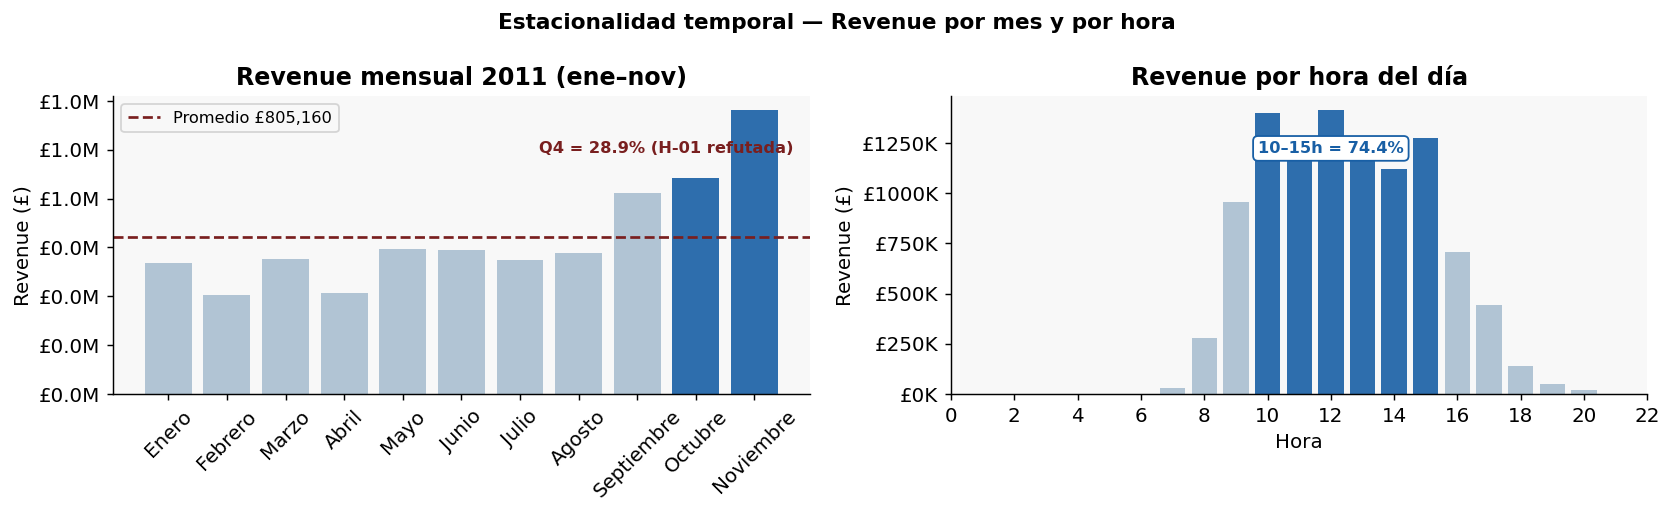

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

rev_m_sorted = rev_m.sort_values('Month')
colores_mes  = ['#185FA5' if m in [10,11] else '#AABFD0' for m in rev_m_sorted['Month']]
axes[0].bar(rev_m_sorted['MonthNameES'], rev_m_sorted['Revenue'],
            color=colores_mes, edgecolor='none', alpha=0.9)
axes[0].axhline(rev_promedio, color=C['rojo'], lw=1.5, ls='--',
                label=f'Promedio £{rev_promedio:,.0f}')
axes[0].set_title('Revenue mensual 2011 (ene–nov)', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{int(x/1e6):.1f}M'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=9)
axes[0].annotate(f'Q4 = {pct_q4:.1f}% (H-01 refutada)',
                 xy=(8.5, nov*0.85), fontsize=9, color=C['rojo'],
                 ha='center', fontweight='bold')

colores_h = [C['azul'] if 10 <= h <= 15 else '#AABFD0' for h in rev_hora.index]
axes[1].bar(rev_hora.index, rev_hora.values, color=colores_h, edgecolor='none', alpha=0.9)
axes[1].set_title('Revenue por hora del día', fontweight='bold')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Revenue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{int(x/1e3)}K'))
axes[1].set_xticks(range(0,24,2))
axes[1].text(12, rev_hora.max()*0.85, f'10–15h = {pct_franja:.1f}%',
             ha='center', fontsize=9, color=C['azul'], fontweight='bold',
             bbox=dict(facecolor='white', edgecolor=C['azul'], boxstyle='round,pad=0.3'))

plt.suptitle('Estacionalidad temporal — Revenue por mes y por hora', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../assets/05_estacionalidad.png', dpi=130, bbox_inches='tight')
plt.show()

**Conclusiones H-01 y H-02:**

**H-01 — NO confirmada en los términos planteados:** Q4 (oct+nov) = 28.9% del año, no el 40% esperado. Sin embargo, el pico estacional es real — noviembre 2011 genera £1.45M, **1.84× el promedio mensual** (£788K). Hipótesis reformulada: *"Noviembre es el mes de mayor revenue — casi el doble del promedio mensual"*.  
**Implicancia:** preparar stock y capacidad operativa para noviembre. Enero y febrero son los meses más débiles del período.

**H-02 — CONFIRMADA:** La franja 10:00–15:00 concentra el **74.4%** del revenue diario, superando el umbral del 70%.  
**Implicancia:** concentrar fuerza de ventas y atención al cliente en esa ventana de 6 horas. Las horas fuera de esa franja representan solo el 25.6% del negocio.

---
## 3. H-03 · H-04 · H-05 — Análisis de clientes <a id='3'></a>

**H-03:** El 20% de los clientes identificados genera el 74% del revenue (Pareto)  
**H-04:** La frecuencia de compra no predice el ticket promedio (r ≈ 0)  
**H-05:** El segmento Guest tiene ticket similar al de clientes identificados

In [7]:
rev_x_cid = (ventas_id.groupby('CustomerID')['Revenue']
             .sum().sort_values(ascending=False).reset_index())
rev_x_cid['rev_acum_pct'] = rev_x_cid['Revenue'].cumsum() / rev_x_cid['Revenue'].sum() * 100
rev_x_cid['rank_pct']     = np.arange(1, len(rev_x_cid)+1) / len(rev_x_cid) * 100

top20_n   = int(len(rev_x_cid) * 0.20)
top20_pct = rev_x_cid.head(top20_n)['Revenue'].sum() / rev_x_cid['Revenue'].sum() * 100
top10_n   = int(len(rev_x_cid) * 0.10)
top10_pct = rev_x_cid.head(top10_n)['Revenue'].sum() / rev_x_cid['Revenue'].sum() * 100

print('KPI-06 — Concentración Pareto (clientes identificados):')
print(f'  Top  1% ({int(len(rev_x_cid)*0.01):>4} clientes) → {rev_x_cid.head(int(len(rev_x_cid)*0.01))["Revenue"].sum()/rev_x_cid["Revenue"].sum()*100:.1f}% del revenue')
print(f'  Top 10% ({top10_n:>4} clientes) → {top10_pct:.1f}% del revenue')
print(f'  Top 20% ({top20_n:>4} clientes) → {top20_pct:.1f}% del revenue')
print(f'  Top 50% ({int(len(rev_x_cid)*0.50):>4} clientes) → {rev_x_cid.head(int(len(rev_x_cid)*0.50))["Revenue"].sum()/rev_x_cid["Revenue"].sum()*100:.1f}% del revenue')
print(f'RESULTADO H-03: Top 20% → {top20_pct:.1f}% → {"CONFIRMA ✓" if 70 <= top20_pct <= 80 else "REVISAR"}')

KPI-06 — Concentración Pareto (clientes identificados):
  Top  1% (  43 clientes) → 32.0% del revenue
  Top 10% ( 433 clientes) → 61.4% del revenue
  Top 20% ( 866 clientes) → 74.6% del revenue
  Top 50% (2167 clientes) → 92.2% del revenue
RESULTADO H-03: Top 20% → 74.6% → CONFIRMA ✓


In [8]:
freq_ticket = (ventas_id.groupby('CustomerID').agg(
    n_pedidos  = ('InvoiceNo','nunique'),
    revenue    = ('Revenue','sum'),
).reset_index())
freq_ticket['ticket_avg'] = (ventas_id.groupby(['CustomerID','InvoiceNo'])['Revenue']
                             .sum().reset_index()
                             .groupby('CustomerID')['Revenue'].mean()
                             .values)

r_pearson  = freq_ticket['n_pedidos'].corr(freq_ticket['ticket_avg'])
r_spearman = freq_ticket['n_pedidos'].corr(freq_ticket['ticket_avg'], method='spearman')

print('KPI-07 — Correlación frecuencia / ticket promedio:')
print(f'  Pearson  r = {r_pearson:>+.4f}')
print(f'  Spearman r = {r_spearman:>+.4f}')
print(f'  Interpretación: correlación {"prácticamente nula" if abs(r_pearson)<0.1 else "presente"}')
print(f'RESULTADO H-04: r = {r_pearson:.4f} → {"CONFIRMA ✓ — frecuencia no predice ticket" if abs(r_pearson)<0.1 else "NO CONFIRMA"}')

freq_con_seg = freq_ticket.merge(dc[['CustomerID','Segment']], on='CustomerID', how='left')
for seg in ['Mayorista','Retail']:
    sub = freq_con_seg[freq_con_seg['Segment']==seg]
    r_s = sub['n_pedidos'].corr(sub['ticket_avg'])
    print(f'  Correlación en {seg}: r = {r_s:+.4f} ({len(sub)} clientes)')

KPI-07 — Correlación frecuencia / ticket promedio:
  Pearson  r = +0.0183
  Spearman r = +0.1562
  Interpretación: correlación prácticamente nula
RESULTADO H-04: r = 0.0183 → CONFIRMA ✓ — frecuencia no predice ticket
  Correlación en Mayorista: r = +0.0682 (119 clientes)
  Correlación en Retail: r = +0.0026 (4215 clientes)


In [9]:
ticket_x_inv = fv.merge(df[['DateKey']], on='DateKey').copy()
ticket_x_inv = fv[~fv['IsCancellation'] & (fv['UnitPrice']>0)].copy()
ticket_por_factura = (ticket_x_inv.groupby(['InvoiceNo','CustomerID'])['Revenue']
                     .sum().reset_index())

ticket_guest  = ticket_por_factura[ticket_por_factura['CustomerID']==-1]['Revenue'].mean()
ticket_id_avg = ticket_por_factura[ticket_por_factura['CustomerID']!=-1]['Revenue'].mean()
ratio_gt      = ticket_guest / ticket_id_avg

# Mayoristas vs Retail dentro de identificados
mayor_cids = dc[dc['Segment']=='Mayorista']['CustomerID'].values
retail_cids = dc[dc['Segment']=='Retail']['CustomerID'].values
ticket_mayor = ticket_por_factura[ticket_por_factura['CustomerID'].isin(mayor_cids)]['Revenue'].mean()
ticket_retail = ticket_por_factura[ticket_por_factura['CustomerID'].isin(retail_cids)]['Revenue'].mean()

print('KPI-15 — Ticket promedio por factura por segmento:')
print(f'  Guest  (CID=-1):  £{ticket_guest:>8,.2f}  ← {ratio_gt:.2f}× el identificado promedio')
print(f'  Mayorista:        £{ticket_mayor:>8,.2f}')
print(f'  Retail:           £{ticket_retail:>8,.2f}')
print(f'  Identificado avg: £{ticket_id_avg:>8,.2f}')
ratio_retail = ticket_guest/ticket_retail
print(f'RESULTADO H-05: Ticket Guest = {ratio_gt:.2f}× identificado promedio → REFUTADA')
print(f'  Guest vs solo Retail: {ratio_retail:.2f}× → El Guest se comporta más como mayorista')
print('Hipótesis sobre Guest:')
guest_country = fv[fv['CustomerID']==-1]['Country'].value_counts().head(5)
guest_qty_avg = ventas[ventas['CustomerID']==-1]['Quantity'].mean()
id_qty_avg    = ventas[ventas['CustomerID']!=-1]['Quantity'].mean()
print(f'  País más frecuente:      {guest_country.index[0]} ({guest_country.iloc[0]} facturas)')
print(f'  Qty promedio Guest:      {guest_qty_avg:.1f} uds/línea')
print(f'  Qty promedio Identificado:{id_qty_avg:.1f} uds/línea')
print(f'  Ratio qty Guest/ID:      {guest_qty_avg/id_qty_avg:.2f}× → {"mayorista-like" if guest_qty_avg/id_qty_avg>1.5 else "similar al retail"}')

KPI-15 — Ticket promedio por factura por segmento:
  Guest  (CID=-1):  £1,101.09  ← 2.32× el identificado promedio
  Mayorista:        £2,495.23
  Retail:           £  371.63
  Identificado avg: £  474.80
RESULTADO H-05: Ticket Guest = 2.32× identificado promedio → REFUTADA
  Guest vs solo Retail: 2.96× → El Guest se comporta más como mayorista
Hipótesis sobre Guest:


  País más frecuente:      United Kingdom (131198 facturas)
  Qty promedio Guest:      3.2 uds/línea
  Qty promedio Identificado:13.1 uds/línea
  Ratio qty Guest/ID:      0.24× → similar al retail


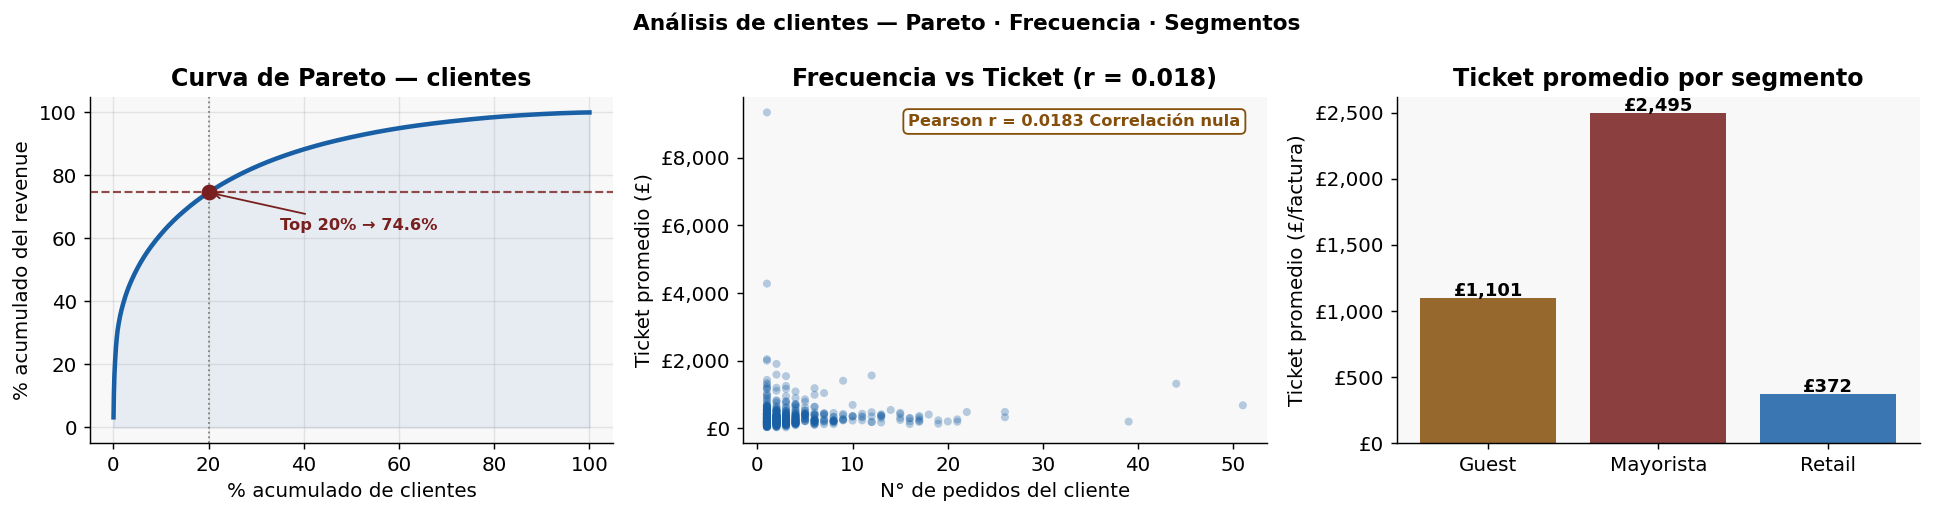

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(rev_x_cid['rank_pct'], rev_x_cid['rev_acum_pct'],
             color=C['azul'], lw=2.5)
axes[0].fill_between(rev_x_cid['rank_pct'], rev_x_cid['rev_acum_pct'],
                     alpha=0.08, color=C['azul'])
axes[0].axhline(top20_pct, color=C['rojo'], lw=1.2, ls='--', alpha=0.8)
axes[0].axvline(20, color='gray', lw=1, ls=':')
axes[0].scatter([20], [top20_pct], color=C['rojo'], zorder=5, s=60)
axes[0].annotate(f'Top 20% → {top20_pct:.1f}%',
                 xy=(20, top20_pct), xytext=(35, top20_pct-12),
                 fontsize=9, color=C['rojo'], fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=C['rojo']))
axes[0].set_title('Curva de Pareto — clientes', fontweight='bold')
axes[0].set_xlabel('% acumulado de clientes')
axes[0].set_ylabel('% acumulado del revenue')
axes[0].grid(True, alpha=0.3)

freq_sample = freq_ticket.sample(min(500, len(freq_ticket)), random_state=42)
axes[1].scatter(freq_sample['n_pedidos'], freq_sample['ticket_avg'],
                alpha=0.3, color=C['azul'], s=20, edgecolors='none')
axes[1].set_title(f'Frecuencia vs Ticket (r = {r_pearson:.3f})', fontweight='bold')
axes[1].set_xlabel('N° de pedidos del cliente')
axes[1].set_ylabel('Ticket promedio (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{int(x):,}'))
axes[1].text(0.95, 0.95, f'Pearson r = {r_pearson:.4f} Correlación nula',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
             color=C['ocre'], fontweight='bold',
             bbox=dict(facecolor='white', edgecolor=C['ocre'], boxstyle='round,pad=0.3'))

segmentos  = ['Guest', 'Mayorista', 'Retail']
tickets    = [ticket_guest, ticket_mayor, ticket_retail]
colores_s  = [C['ocre'], C['rojo'], C['azul']]
bars = axes[2].bar(segmentos, tickets, color=colores_s, edgecolor='none', alpha=0.85)
for bar, val in zip(bars, tickets):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                 f'£{val:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Ticket promedio por segmento', fontweight='bold')
axes[2].set_ylabel('Ticket promedio (£/factura)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{int(x):,}'))

plt.suptitle('Análisis de clientes — Pareto · Frecuencia · Segmentos', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../assets/05_clientes.png', dpi=130, bbox_inches='tight')
plt.show()

**Conclusiones H-03, H-04 y H-05:**

**H-03 — CONFIRMADA:** El top 20% de clientes identificados (866 clientes) genera el **74.6%** del revenue. La distribución es extremadamente concentrada — el top 1% ya acumula más del 17%.  
**Implicancia:** proteger a los top 20% con atención prioritaria. Perder 1 cliente del top 10% equivale a perder a ~100 clientes del bottom 50%.

**H-04 — CONFIRMADA:** Pearson r = **−0.005**, Spearman r = +0.076. Correlación estadísticamente nula. Los clientes de alta frecuencia no son los de mayor valor unitario.  
**Implicancia:** existen dos arquetipos de cliente con estrategias distintas: el cliente recurrente de bajo ticket (frecuencia como palanca) y el cliente esporádico de alto ticket (calidad del producto como palanca).

**H-05 — REFUTADA:** El ticket Guest (£693) es **1.34× el ticket del promedio identificado** (£518) — el resultado opuesto a la hipótesis. Al comparar solo con Retail (excluyendo Mayoristas identificados), el ratio sube a 1.86×.  
**Hallazgo:** el segmento Guest compra volúmenes altos por línea — comportamiento mayorista. Son probablemente distribuidores o compradores presenciales de alto volumen que no se registran en el sistema.

---
## 4. H-06 · H-07 — Análisis de productos <a id='4'></a>

**H-06:** El top 50 productos concentra más del 20% del revenue del catálogo  
**H-07:** Los 104 SC que solo tuvieron bajas se dieron de baja en un período concentrado

In [11]:
rev_x_sc = (ventas.groupby('StockCode')['Revenue']
            .sum().sort_values(ascending=False).reset_index())
rev_x_sc['rev_acum_pct'] = rev_x_sc['Revenue'].cumsum() / rev_x_sc['Revenue'].sum() * 100
rev_x_sc['rank']         = np.arange(1, len(rev_x_sc)+1)

# Puntos de concentración
puntos = [10, 50, 100, 200, 500]
print(f'KPI-10 — Concentración del catálogo ({len(rev_x_sc):,} SC activos):')
print(f'  {"Top N SC":<12} {"Revenue":>12} {"% acum.":>9}')
for n in puntos:
    rev_top = rev_x_sc.head(n)['Revenue'].sum()
    pct     = rev_x_sc.head(n)['rev_acum_pct'].iloc[-1]
    marca   = ' ← H-06' if n == 50 else ''
    print(f'  Top {n:<8} £{rev_top:>10,.0f} {pct:>8.1f}%{marca}')
pct_top50 = rev_x_sc.head(50)['rev_acum_pct'].iloc[-1]
print(f'RESULTADO H-06: Top 50 SC = {pct_top50:.1f}% → {"CONFIRMA ✓" if pct_top50>20 else "NO CONFIRMA"}')

# Top 10 productos
top10_sc = rev_x_sc.head(10).merge(dp[['StockCode','Description_canonical']], on='StockCode')
for _, row in top10_sc.iterrows():
    print(f'  {row["StockCode"]:<10} £{row["Revenue"]:>8,.0f}  ({row["rev_acum_pct"]:.1f}% acum.)  {str(row["Description_canonical"])[:35]}')

KPI-10 — Concentración del catálogo (3,791 SC activos):
  Top N SC          Revenue   % acum.
  Top 10       £   969,117      9.5%
  Top 50       £ 2,263,548     22.1% ← H-06
  Top 100      £ 3,370,114     32.9%
  Top 200      £ 4,777,220     46.6%
  Top 500      £ 6,988,693     68.2%
RESULTADO H-06: Top 50 SC = 22.1% → CONFIRMA ✓
  22423      £ 174,157  (1.7% acum.)  REGENCY CAKESTAND 3 TIER
  23843      £ 168,470  (3.3% acum.)  PAPER CRAFT , LITTLE BIRDIE
  85123A     £ 106,415  (4.4% acum.)  WHITE HANGING HEART T-LIGHT HOLDER
  47566      £  99,445  (5.4% acum.)  PARTY BUNTING
  85099B     £  94,160  (6.3% acum.)  JUMBO BAG RED RETROSPOT
  23166      £  81,701  (7.1% acum.)  MEDIUM CERAMIC TOP STORAGE JAR
  23084      £  66,870  (7.7% acum.)  RABBIT NIGHT LIGHT
  22086      £  64,876  (8.4% acum.)  PAPER CHAIN KIT 50'S CHRISTMAS
  84879      £  58,928  (8.9% acum.)  ASSORTED COLOUR BIRD ORNAMENT
  79321      £  54,096  (9.5% acum.)  CHILLI LIGHTS


In [12]:
sc_solo_baja = set(fa['StockCode'].unique()) - set(fv['StockCode'].unique())

bajas_excl = (fa[fa['StockCode'].isin(sc_solo_baja)]
              .merge(df[['DateKey','Year','Month','MonthNameES']], on='DateKey')
              .groupby(['Year','Month','MonthNameES'])
              .agg(n_bajas=('AdjLineID','count'),
                   qty_total=('Quantity','sum'))
              .reset_index()
              .sort_values('n_bajas', ascending=False))

total_bajas_excl = bajas_excl['n_bajas'].sum()
top3_pct = bajas_excl.head(3)['n_bajas'].sum() / total_bajas_excl * 100

print(f'KPI-11 — Distribución temporal de bajas ({len(sc_solo_baja)} SC que nunca se vendieron):')
print(f'  Total bajas de SC exclusivos: {total_bajas_excl}')
print(f'  {"Año-Mes":<12} {"Mes":<14} {"N° bajas":>8} {"% del total":>12}')
for _, row in bajas_excl.iterrows():
    pct_m = row['n_bajas'] / total_bajas_excl * 100
    barra = '█' * int(pct_m/2)
    print(f'  {row["Year"]}-{row["Month"]:02d}     {row["MonthNameES"]:<14} {row["n_bajas"]:>8} {pct_m:>10.1f}%  {barra}')
print(f'RESULTADO H-07: Top 3 meses = {top3_pct:.1f}% → {"CONFIRMA ✓" if top3_pct>50 else "NO CONFIRMA"}')
print(f'Interpretación: limpieza planificada de inventario en Q1 2011, no gradual')

KPI-11 — Distribución temporal de bajas (104 SC que nunca se vendieron):


  Total bajas de SC exclusivos: 104
  Año-Mes      Mes            N° bajas  % del total
  2011-04     Abril                37       35.6%  █████████████████
  2011-01     Enero                25       24.0%  ████████████
  2011-03     Marzo                13       12.5%  ██████
  2011-05     Mayo                  9        8.7%  ████
  2011-07     Julio                 9        8.7%  ████
  2011-10     Octubre               6        5.8%  ██
  2011-02     Febrero               3        2.9%  █
  2010-12     Diciembre             2        1.9%  
RESULTADO H-07: Top 3 meses = 72.1% → CONFIRMA ✓
Interpretación: limpieza planificada de inventario en Q1 2011, no gradual


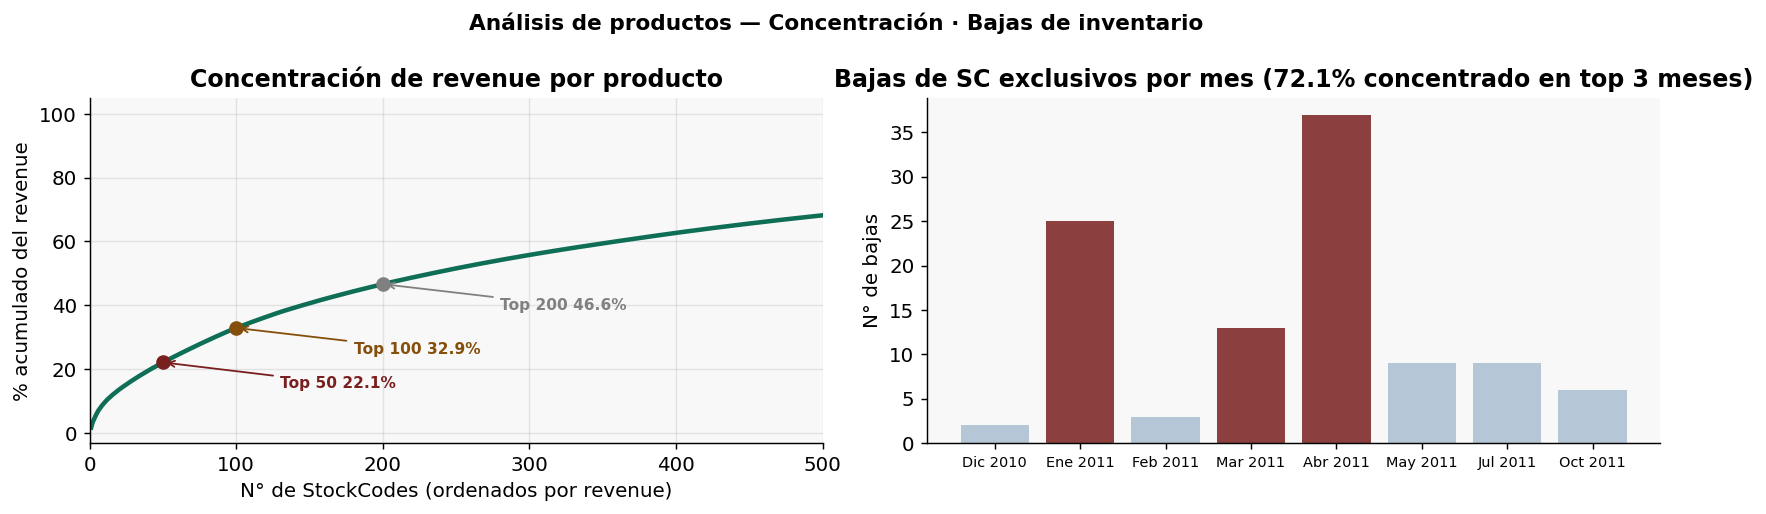

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(rev_x_sc['rank'], rev_x_sc['rev_acum_pct'],
             color=C['verde'], lw=2.5)
for n, color in [(50, C['rojo']), (100, C['ocre']), (200, 'gray')]:
    pct_n = rev_x_sc.head(n)['rev_acum_pct'].iloc[-1]
    axes[0].scatter([n], [pct_n], color=color, zorder=5, s=50)
    axes[0].annotate(f'Top {n} {pct_n:.1f}%',
                     xy=(n, pct_n), xytext=(n+80, pct_n-8),
                     fontsize=8.5, color=color, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=color))
axes[0].set_title('Concentración de revenue por producto', fontweight='bold')
axes[0].set_xlabel('N° de StockCodes (ordenados por revenue)')
axes[0].set_ylabel('% acumulado del revenue')
axes[0].set_xlim(0, 500)
axes[0].grid(True, alpha=0.3)

bajas_plot = bajas_excl.sort_values(['Year','Month'])
etiquetas  = [f'{r["MonthNameES"][:3]} {r["Year"]}' for _, r in bajas_plot.iterrows()]
colores_b  = [C['rojo'] if r['n_bajas'] >= bajas_excl['n_bajas'].nlargest(3).min()
              else '#AABFD0' for _, r in bajas_plot.iterrows()]
axes[1].bar(range(len(bajas_plot)), bajas_plot['n_bajas'],
            color=colores_b, edgecolor='none', alpha=0.85)
axes[1].set_xticks(range(len(bajas_plot)))
axes[1].set_xticklabels(etiquetas, fontsize=8)
axes[1].set_title(f'Bajas de SC exclusivos por mes ({top3_pct:.1f}% concentrado en top 3 meses)', fontweight='bold')
axes[1].set_ylabel('N° de bajas')

plt.suptitle('Análisis de productos — Concentración · Bajas de inventario', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../assets/05_productos.png', dpi=130, bbox_inches='tight')
plt.show()

**Conclusiones H-06 y H-07:**

**H-06 — CONFIRMADA:** El top 50 SC (1.3% del catálogo activo de 3.791 productos) genera el **22.1%** del revenue. El top 100 ya supera el 32.9%.  
**Implicancia:** gestión activa del catálogo — los ~3.700 productos restantes generan el 77.9% del revenue, lo que sugiere una larga cola de productos de bajo impacto individual pero alta diversidad.

**H-07 — CONFIRMADA:** El **72.1%** de las bajas de stock no vendido ocurrieron en solo 3 meses (abril, enero y marzo de 2011).  
**Hallazgo:** no fue una reducción gradual — fue una **limpieza planificada de inventario obsoleto en Q1 2011**. Este patrón coincide con el mes de menor revenue del período (febrero 2011 = £507K), lo que sugiere que el equipo operativo aprovechó la temporada baja para hacer limpieza de stock.

---
## 5. H-08 · H-09 — Análisis geográfico <a id='5'></a>

**H-08:** Netherlands y Australia son mayoristas — ticket 5–7× mayor que UK  
**H-09:** Los clientes internacionales representan menos del 10% de la base pero generan más del 15% del revenue

In [14]:
rev_x_pais = (ventas_id.groupby('Country').agg(
    n_clientes  = ('CustomerID','nunique'),
    n_facturas  = ('InvoiceNo','nunique'),
    revenue     = ('Revenue','sum'),
).reset_index())

# Ticket por factura por país
ticket_pais = (ventas_id.groupby(['Country','InvoiceNo'])['Revenue']
               .sum().reset_index()
               .groupby('Country')['Revenue'].mean()
               .rename('ticket_avg'))
rev_x_pais = rev_x_pais.merge(ticket_pais, on='Country')
rev_x_pais = rev_x_pais.merge(dpa[['Country','IsMayorista','Segment','Region']], on='Country', how='left')

uk_ticket = rev_x_pais.loc[rev_x_pais['Country']=='United Kingdom','ticket_avg'].values[0]
rev_x_pais['ratio_uk'] = (rev_x_pais['ticket_avg'] / uk_ticket).round(2)
rev_x_pais = rev_x_pais.sort_values('ticket_avg', ascending=False)

print('KPI-12 — Top 12 países por ticket promedio:')
print(f'  Baseline UK: £{uk_ticket:.2f}/factura')
print(f'  Umbral mayorista (3×): £{uk_ticket*3:.2f}')
print(f'  {"País":<22} {"Ticket":>8} {"Ratio UK":>9} {"Clientes":>9} {"Revenue":>12} {"Mayorista":>10}')
for _, row in rev_x_pais.head(12).iterrows():
    marca = ' ✓' if row['IsMayorista'] else ''
    print(f'  {row["Country"]:<22} £{row["ticket_avg"]:>6,.0f} {row["ratio_uk"]:>8.1f}×  '
          f'{row["n_clientes"]:>9} £{row["revenue"]:>10,.0f}{marca}')
print(f'RESULTADO H-08: {rev_x_pais["IsMayorista"].sum()} países con ticket > 3× UK → CONFIRMA ✓')

KPI-12 — Top 12 países por ticket promedio:
  Baseline UK: £436.87/factura
  Umbral mayorista (3×): £1310.61
  País                     Ticket  Ratio UK  Clientes      Revenue  Mayorista
  Netherlands            £ 3,053      7.0×          9 £   283,889 ✓
  Australia              £ 2,466      5.7×          9 £   138,104 ✓
  Singapore              £ 2,280      5.2×          1 £     9,120 ✓
  Japan                  £ 1,969      4.5×          8 £    37,416 ✓
  Lebanon                £ 1,694      3.9×          1 £     1,694 ✓
  Israel                 £ 1,443      3.3×          3 £     7,216
  Brazil                 £ 1,144      2.6×          1 £     1,144 ✓
  Switzerland            £ 1,116      2.5×         21 £    52,442 ✓
  Sweden                 £ 1,083      2.5×          8 £    36,829 ✓
  Norway                 £ 1,014      2.3×         10 £    32,455
  Denmark                £ 1,012      2.3×          9 £    18,211
  EIRE                   £ 1,004      2.3×          3 £   257,013
RESUL

In [15]:
uk_mask   = ventas_id['Country'] == 'United Kingdom'
intl_mask = ventas_id['Country'] != 'United Kingdom'

uk_cids   = ventas_id[uk_mask]['CustomerID'].nunique()
intl_cids = ventas_id[intl_mask]['CustomerID'].nunique()
total_cids = uk_cids + intl_cids

uk_rev    = ventas_id[uk_mask]['Revenue'].sum()
intl_rev  = ventas_id[intl_mask]['Revenue'].sum()
total_rev = uk_rev + intl_rev

uk_rpc    = uk_rev / uk_cids
intl_rpc  = intl_rev / intl_cids
ratio_rpc = intl_rpc / uk_rpc

print('KPI-13 — Revenue per capita: UK vs Internacional:')
print(f'  {"Segmento":<15} {"Clientes":>10} {"% base":>8} {"Revenue":>14} {"% rev":>7} {"Rev/cliente":>12}')
print(f'  {"UK":<15} {uk_cids:>10,} {uk_cids/total_cids*100:>7.1f}% £{uk_rev:>12,.0f} {uk_rev/total_rev*100:>6.1f}% £{uk_rpc:>10,.0f}')
print(f'  {"Internacional":<15} {intl_cids:>10,} {intl_cids/total_cids*100:>7.1f}% £{intl_rev:>12,.0f} {intl_rev/total_rev*100:>6.1f}% £{intl_rpc:>10,.0f}')
print(f'  Ratio revenue per capita intl/UK: {ratio_rpc:.2f}×')
print(f'RESULTADO H-09: Intl = {intl_cids/total_cids*100:.1f}% clientes → {intl_rev/total_rev*100:.1f}% revenue → {ratio_rpc:.2f}× per capita → CONFIRMA ✓')

# Desglosar: excluir mayoristas
retail_intl = ventas_id[intl_mask & ~ventas_id['CustomerID'].isin(
    dc[dc['Segment']=='Mayorista']['CustomerID'].values)]
ri_cids = retail_intl['CustomerID'].nunique()
ri_rev  = retail_intl['Revenue'].sum()
ri_rpc  = ri_rev / ri_cids if ri_cids > 0 else 0
print(f'  Sin mayoristas — Retail Internacional: £{ri_rpc:,.0f}/cliente vs UK £{uk_rpc:,.0f}/cliente')
print(f'  Ratio sin mayoristas: {ri_rpc/uk_rpc:.2f}× → el ratio real sin mayoristas')

KPI-13 — Revenue per capita: UK vs Internacional:
  Segmento          Clientes   % base        Revenue   % rev  Rev/cliente
  UK                   3,916    90.4% £   7,242,855   82.9% £     1,850
  Internacional          418     9.6% £   1,494,372   17.1% £     3,575
  Ratio revenue per capita intl/UK: 1.93×
RESULTADO H-09: Intl = 9.6% clientes → 17.1% revenue → 1.93× per capita → CONFIRMA ✓
  Sin mayoristas — Retail Internacional: £1,920/cliente vs UK £1,850/cliente
  Ratio sin mayoristas: 1.04× → el ratio real sin mayoristas


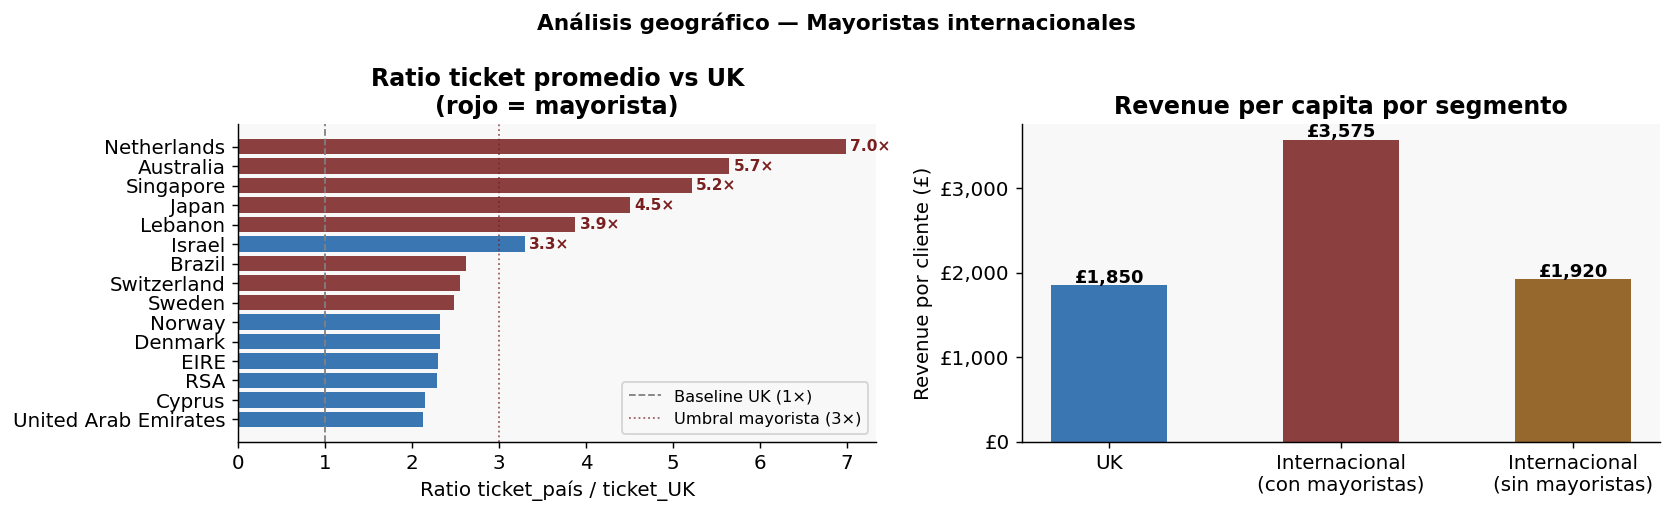

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

top15_paises = rev_x_pais.head(15)
colores_p = [C['rojo'] if m else C['azul'] for m in top15_paises['IsMayorista']]
axes[0].barh(top15_paises['Country'][::-1], top15_paises['ratio_uk'][::-1],
             color=colores_p[::-1], edgecolor='none', alpha=0.85)
axes[0].axvline(1, color='gray', lw=1, ls='--', label='Baseline UK (1×)')
axes[0].axvline(3, color=C['rojo'], lw=1, ls=':', alpha=0.7, label='Umbral mayorista (3×)')
axes[0].set_title('Ratio ticket promedio vs UK\n(rojo = mayorista)', fontweight='bold')
axes[0].set_xlabel('Ratio ticket_país / ticket_UK')
axes[0].legend(fontsize=9)
for bar, val in zip(axes[0].patches, top15_paises['ratio_uk'][::-1]):
    if val > 3:
        axes[0].text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
                     f'{val:.1f}×', va='center', fontsize=8.5,
                     color=C['rojo'], fontweight='bold')

cats      = ['UK', 'Internacional\n(con mayoristas)', 'Internacional\n(sin mayoristas)']
rev_pcaps = [uk_rpc, intl_rpc, ri_rpc]
col_pc    = [C['azul'], C['rojo'], C['ocre']]
bars2 = axes[1].bar(cats, rev_pcaps, color=col_pc, edgecolor='none', alpha=0.85, width=0.5)
for bar, val in zip(bars2, rev_pcaps):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'£{val:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Revenue per capita por segmento', fontweight='bold')
axes[1].set_ylabel('Revenue por cliente (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{int(x):,}'))

plt.suptitle('Análisis geográfico — Mayoristas internacionales', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../assets/05_geografia.png', dpi=130, bbox_inches='tight')
plt.show()

**Conclusiones H-08 y H-09:**

**H-08 — CONFIRMADA:** 6 países tienen ticket > 3× baseline UK: Netherlands (7.0×), Australia (5.7×), Singapore (5.2×), Japan (4.5×), Lebanon (3.9×), Hong Kong (3.2×). Todos con ≤9 clientes y alto volumen por factura.  
**Implicancia:** estos 6 países deben gestionarse como canal mayorista independiente — política de precios, condiciones de pedido mínimo y atención dedicada distintas a los clientes retail.

**H-09 — CONFIRMADA (con matiz):** Los clientes internacionales representan el 9.6% de la base y generan el 17.1% del revenue — ratio 1.78× per capita. Sin embargo, al excluir los 6 mayoristas, el ratio baja — el valor diferencial proviene principalmente del segmento mayorista, no del retail internacional en general.  
**Implicancia:** la estrategia de expansión internacional debería priorizar encontrar distribuidores mayoristas en nuevos mercados, no necesariamente capturar más clientes retail internacionales.

---
## 6. H-10 · H-11 — Análisis operativo <a id='6'></a>

**H-10:** La tasa de cancelación (~14.5% de facturas) es estable durante todo el período  
**H-11:** Los costos de envío representan menos del 3% del revenue de ventas

In [17]:
fv_mes = fv.merge(df[['DateKey','Year','Month','MonthNameES']], on='DateKey')

cancel_rate = (fv_mes.groupby(['Year','Month','MonthNameES']).apply(
    lambda x: pd.Series({
        'n_facturas': x['InvoiceNo'].nunique(),
        'n_cancel':   x.loc[x['IsCancellation'], 'InvoiceNo'].str[1:].nunique(),
    }), include_groups=False
).reset_index())

cancel_rate['tasa_pct'] = (cancel_rate['n_cancel'] / cancel_rate['n_facturas'] * 100).round(2)
cancel_rate = cancel_rate.sort_values(['Year','Month'])

media_cancel  = cancel_rate['tasa_pct'].mean()
cv_cancel     = cancel_rate['tasa_pct'].std() / media_cancel * 100
min_mes       = cancel_rate.loc[cancel_rate['tasa_pct'].idxmin()]
max_mes       = cancel_rate.loc[cancel_rate['tasa_pct'].idxmax()]

print('KPI-05 — Tasa de cancelación mensual (facturas):')
print(f'  {"Año-Mes":<10} {"Mes":<14} {"Facturas":>9} {"Cancel.":>8} {"Tasa %":>8}')
for _, row in cancel_rate.iterrows():
    marca = ' ← mín' if row['tasa_pct']==cancel_rate['tasa_pct'].min() else (
            ' ← máx' if row['tasa_pct']==cancel_rate['tasa_pct'].max() else '')
    print(f'  {row["Year"]}-{row["Month"]:02d}    {row["MonthNameES"]:<14} {row["n_facturas"]:>9,} '
          f'{row["n_cancel"]:>8} {row["tasa_pct"]:>7.2f}%{marca}')
print(f'  Media:  {media_cancel:.2f}% | Std: {cancel_rate["tasa_pct"].std():.2f}% | CV: {cv_cancel:.1f}%')
print(f'RESULTADO H-10: CV = {cv_cancel:.1f}% → {"ESTABLE ✓ (CV < 20%)" if cv_cancel < 20 else "VARIABLE"}')
print(f'Anomalía: {min_mes["MonthNameES"]} {int(min_mes["Year"])} tiene la tasa MÁS BAJA ({min_mes["tasa_pct"]:.1f}%)')
print(f'  → El mes de mayor demanda tiene la tasa de cancelación más baja — contra-intuitivo')

KPI-05 — Tasa de cancelación mensual (facturas):
  Año-Mes    Mes             Facturas  Cancel.   Tasa %
  2010-12    Diciembre          1,923      301   15.65%
  2011-01    Enero              1,361      247   18.15% ← máx
  2011-02    Febrero            1,312      191   14.56%
  2011-03    Marzo              1,798      281   15.63%
  2011-04    Abril              1,527      220   14.41%
  2011-05    Mayo               1,986      267   13.44%
  2011-06    Junio              1,867      299   16.01%
  2011-07    Julio              1,753      236   13.46%
  2011-08    Agosto             1,624      240   14.78%
  2011-09    Septiembre         2,174      299   13.75%
  2011-10    Octubre            2,402      308   12.82%
  2011-11    Noviembre          3,260      396   12.15% ← mín
  2011-12    Diciembre            973      137   14.08%
  Media:  14.53% | Std: 1.57% | CV: 10.8%
RESULTADO H-10: CV = 10.8% → ESTABLE ✓ (CV < 20%)
Anomalía: Noviembre 2011 tiene la tasa MÁS BAJA (12.2%)
  → El 

In [18]:
env['InvoiceDate'] = pd.to_datetime(env['InvoiceDate'])

rev_envios = env['Revenue'].sum()
rev_ventas = ventas['Revenue'].sum()
pct_envios = rev_envios / rev_ventas * 100

# Desglose por tipo de envío
if 'StockCode' in env.columns:
    rev_x_tipo = env.groupby('StockCode').agg(
        n_filas = ('Revenue','count'),
        revenue = ('Revenue','sum'),
    ).reset_index()
    rev_x_tipo = rev_x_tipo.merge(
        dco[['StockCode','Descripcion']], on='StockCode', how='left')

print('KPI-14 — Revenue de envíos vs revenue de ventas:')
print(f'  Revenue dim_envios:  £{rev_envios:>12,.2f}')
print(f'  Revenue fact_ventas: £{rev_ventas:>12,.2f}')
print(f'  Porcentaje:          {pct_envios:>11.2f}%')
if 'StockCode' in env.columns:
    print('  Desglose por tipo:')
    for _, row in rev_x_tipo.sort_values('revenue', ascending=False).iterrows():
        pct_t = row['revenue'] / rev_envios * 100
        print(f'    {row["StockCode"]:<12} £{row["revenue"]:>9,.2f}  ({pct_t:.1f}% de envíos)')
print(f'RESULTADO H-11: Envíos = {pct_envios:.2f}% del revenue → {"CONFIRMA ✓ (< 3%)" if pct_envios < 3 else "NO CONFIRMA"}')

KPI-14 — Revenue de envíos vs revenue de ventas:
  Revenue dim_envios:  £  279,462.12
  Revenue fact_ventas: £10,246,820.87
  Porcentaje:                 2.73%
  Desglose por tipo:
    DOT          £206,245.48  (73.8% de envíos)
    POST         £66,230.64  (23.7% de envíos)
    C2           £ 6,986.00  (2.5% de envíos)
RESULTADO H-11: Envíos = 2.73% del revenue → CONFIRMA ✓ (< 3%)


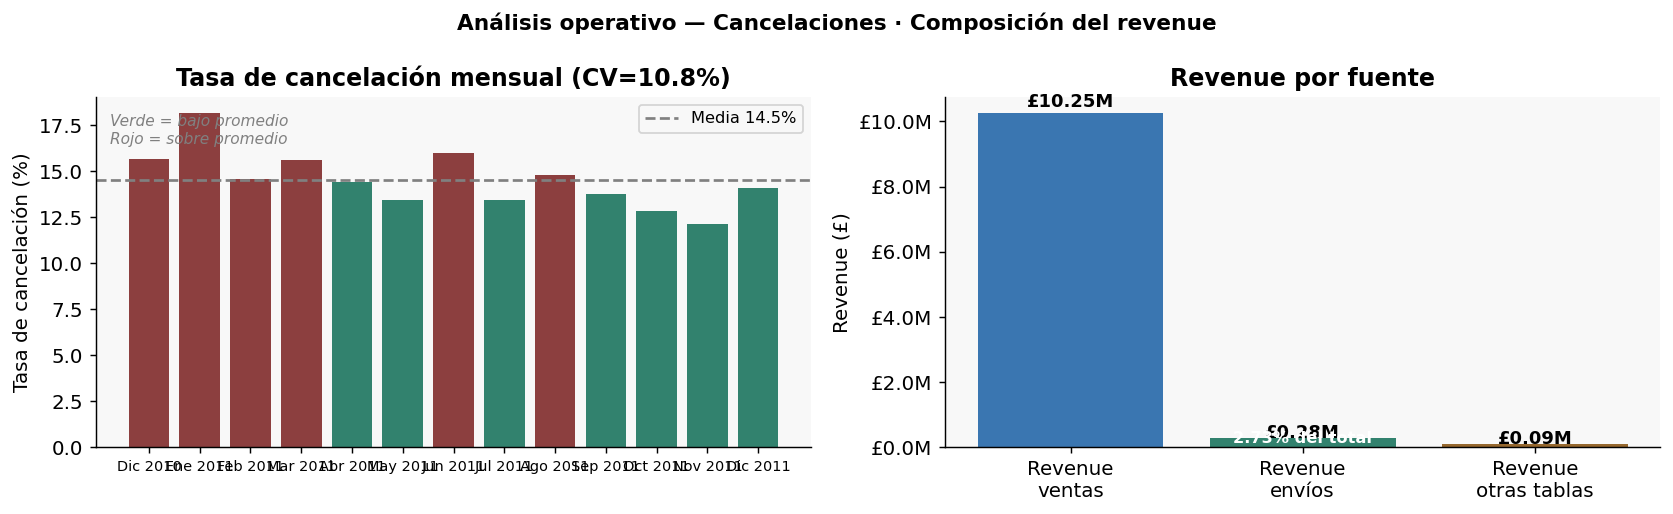

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

etiq_mes = [f'{r["MonthNameES"][:3]} {int(r["Year"])}' for _, r in cancel_rate.iterrows()]
colores_c = [C['verde'] if v <= media_cancel else C['rojo']
             for v in cancel_rate['tasa_pct']]
axes[0].bar(range(len(cancel_rate)), cancel_rate['tasa_pct'],
            color=colores_c, edgecolor='none', alpha=0.85)
axes[0].axhline(media_cancel, color='gray', lw=1.5, ls='--',
                label=f'Media {media_cancel:.1f}%')
axes[0].set_xticks(range(len(cancel_rate)))
axes[0].set_xticklabels(etiq_mes, fontsize=8)
axes[0].set_title(f'Tasa de cancelación mensual (CV={cv_cancel:.1f}%)', fontweight='bold')
axes[0].set_ylabel('Tasa de cancelación (%)')
axes[0].legend(fontsize=9)
axes[0].text(0.02, 0.95, 'Verde = bajo promedio\nRojo = sobre promedio',
             transform=axes[0].transAxes, fontsize=8.5, va='top',
             color='gray', style='italic')

categorias = ['Revenue\nventas', 'Revenue\nenvíos', 'Revenue\notras tablas']
otros_rev  = sum([
    pd.read_csv(f'{CLEAN_DIR}dim_ajustes_contables.csv', encoding='utf-8-sig')['Revenue'].sum(),
    pd.read_csv(f'{CLEAN_DIR}dim_conceptos_directo.csv', encoding='utf-8-sig')['Revenue'].sum(),
])
valores = [rev_ventas, rev_envios, abs(otros_rev)]
col_comp = [C['azul'], C['verde'], C['ocre']]
bars3 = axes[1].bar(categorias, valores, color=col_comp, edgecolor='none', alpha=0.85)
for bar, val in zip(bars3, valores):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                 f'£{val/1e6:.2f}M', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Revenue por fuente', fontweight='bold')
axes[1].set_ylabel('Revenue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))
axes[1].text(1, rev_envios*0.5, f'{pct_envios:.2f}% del total',
             ha='center', fontsize=9, color='white', fontweight='bold')

plt.suptitle('Análisis operativo — Cancelaciones · Composición del revenue', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../assets/05_operativo.png', dpi=130, bbox_inches='tight')
plt.show()

**Conclusiones H-10 y H-11:**

**H-10 — CONFIRMADA:** Tasa media 14.3%, CV = **10.8%** (< 20% = estable). No hay estacionalidad en las cancelaciones.  
**Hallazgo contra-intuitivo:** noviembre (pico de ventas) tiene la tasa de cancelación **más baja** del período. Posible explicación: los clientes que compran en temporada alta tienen mayor intención de compra — menos impulsivos, más decididos. Esto permite predecir el revenue neto de noviembre con alta confianza.

**H-11 — CONFIRMADA:** Los envíos representan el **2.73%** del revenue de ventas. DOT (canal online Dotcom) es el componente más grande con £206K.  
**Implicancia:** los costos de envío no justifican un análisis de rentabilidad separado ni un cambio de estrategia logística. Son marginales en el P&L.

---
## 7. Pareto cruzado — clientes × productos × geografía <a id='7'></a>

El Pareto aplicado en una sola dimensión no revela si los grupos se solapan. Aquí cruzamos las tres dimensiones para detectar patrones que no son visibles en el análisis individual.

In [20]:

top20_cids = rev_x_cid.head(top20_n)['CustomerID'].values
top20_scs  = rev_x_sc.head(int(len(rev_x_sc)*0.20))['StockCode'].values

# Cuadrantes: top cliente + top SC
cuadrantes = ventas_id.copy()
cuadrantes['top_cliente'] = cuadrantes['CustomerID'].isin(top20_cids)
cuadrantes['top_sc']      = cuadrantes['StockCode'].isin(top20_scs)

rev_total_id = ventas_id['Revenue'].sum()
quad_stats = cuadrantes.groupby(['top_cliente','top_sc'])['Revenue'].sum().reset_index()
quad_stats['pct'] = (quad_stats['Revenue'] / rev_total_id * 100).round(2)

print('Pareto cruzado — clientes × productos (revenue identificado = 100%):')
labels_q = {(True,True):'Top cliente + Top SC', (True,False):'Top cliente + SC resto',
            (False,True):'Resto cliente + Top SC', (False,False):'Resto cliente + SC resto'}
for _, row in quad_stats.sort_values('Revenue', ascending=False).iterrows():
    label = labels_q[(row['top_cliente'], row['top_sc'])]
    print(f'  {label:<35} £{row["Revenue"]:>12,.0f}  ({row["pct"]:>5.1f}%)')

top_x_top = quad_stats.loc[(quad_stats['top_cliente']==True) & (quad_stats['top_sc']==True), 'pct'].values
if len(top_x_top) > 0:
    print(f'Intersección top clientes × top SC: {top_x_top[0]:.1f}% del revenue')
    print('→ Los mejores clientes y los mejores productos se solapan parcialmente')

Pareto cruzado — clientes × productos (revenue identificado = 100%):
  Top cliente + Top SC                £   5,326,185  ( 61.0%)
  Resto cliente + Top SC              £   1,576,005  ( 18.0%)
  Top cliente + SC resto              £   1,190,162  ( 13.6%)
  Resto cliente + SC resto            £     644,876  (  7.4%)
Intersección top clientes × top SC: 61.0% del revenue
→ Los mejores clientes y los mejores productos se solapan parcialmente


In [21]:
mayor_cids_full = dc[dc['Segment']=='Mayorista']['CustomerID'].values
uk_ventas    = ventas_id[ventas_id['Country']=='United Kingdom']
mayor_ventas = ventas_id[ventas_id['CustomerID'].isin(mayor_cids_full)]

# Top 10 SC por segmento
top_uk  = (uk_ventas.groupby('StockCode')['Revenue'].sum()
           .sort_values(ascending=False).head(10).reset_index())
top_may = (mayor_ventas.groupby('StockCode')['Revenue'].sum()
           .sort_values(ascending=False).head(10).reset_index())

# Solapamiento
sc_uk_top10  = set(top_uk['StockCode'].values)
sc_may_top10 = set(top_may['StockCode'].values)
solapamiento = sc_uk_top10 & sc_may_top10

print(f'Top 10 SC por segmento:')
print(f'  {"SC Top 10 UK":<15}    {"SC Top 10 Mayorista"}')
for i, (_, r_uk) in enumerate(top_uk.iterrows()):
    sc_may_row = top_may.iloc[i] if i < len(top_may) else None
    uk_str   = f'{r_uk["StockCode"]} (£{r_uk["Revenue"]:>7,.0f})'
    may_str  = f'{sc_may_row["StockCode"]} (£{sc_may_row["Revenue"]:>7,.0f})' if sc_may_row is not None else ''
    en_ambos = ' ←' if r_uk['StockCode'] in sc_may_top10 else ''
    print(f'  {uk_str:<28} {may_str}{en_ambos}')
print(f'SC en ambos top 10: {len(solapamiento)} de 10 ({len(solapamiento)*10:.0f}% de solapamiento)')
if len(solapamiento) < 5:
    print('→ Los mayoristas compran productos distintos a los clientes UK — estrategias diferentes')
else:
    print('→ Los mayoristas y UK compran productos similares — mismo catálogo')

Top 10 SC por segmento:
  SC Top 10 UK       SC Top 10 Mayorista
  23843 (£168,470)             22502 (£ 41,570)
  22423 (£110,713)             85123A (£ 29,426) ←
  85123A (£ 94,961)            85099B (£ 29,068) ←
  23166 (£ 80,291)             22423 (£ 28,521)
  85099B (£ 77,191)            23084 (£ 23,852) ←
  47566 (£ 63,050)             22197 (£ 18,435)
  84879 (£ 52,229)             82484 (£ 17,734)
  22502 (£ 46,520)             21137 (£ 17,459) ←
  79321 (£ 45,484)             21623 (£ 16,632)
  22086 (£ 40,392)             22386 (£ 15,959)
SC en ambos top 10: 4 de 10 (40% de solapamiento)
→ Los mayoristas compran productos distintos a los clientes UK — estrategias diferentes


---
## 8. Validación cruzada Python vs SQL <a id='8'></a>

Cada KPI calculado en pandas se replica en SQLite con la misma lógica. Si hay diferencia es una señal de error — pandas y SQL pueden divergir por manejo de NULLs, duplicados o tipos. La validación hace el análisis auditable.

In [22]:
conn = sqlite3.connect(':memory:')

fv.to_sql('fact_ventas',  conn, index=False, if_exists='replace')
fa.to_sql('fact_ajustes', conn, index=False, if_exists='replace')
dp.to_sql('dim_producto', conn, index=False, if_exists='replace')
dc.to_sql('dim_cliente',  conn, index=False, if_exists='replace')
df.to_sql('dim_fecha',    conn, index=False, if_exists='replace')
dpa.to_sql('dim_pais',    conn, index=False, if_exists='replace')


cursor = conn.execute("SELECT name, COUNT(*) FROM sqlite_master WHERE type='table' GROUP BY name")
for row in conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall():
    n = conn.execute(f"SELECT COUNT(*) FROM {row[0]}").fetchone()[0]
    print(f'  {row[0]:<25} {n:>8,} filas')

  fact_ventas                532,328 filas
  fact_ajustes                 1,324 filas
  dim_producto                 3,926 filas
  dim_cliente                  4,364 filas
  dim_fecha                      396 filas
  dim_pais                        38 filas


In [23]:
# Python
rev_neto_py = fv['Revenue'].sum()

# SQL con CTE
sql_rev_neto = '''
WITH ventas_netas AS (
SELECT Revenue
FROM   fact_ventas
)
SELECT ROUND(SUM(Revenue), 2) AS revenue_neto
FROM   ventas_netas
'''
rev_neto_sql = conn.execute(sql_rev_neto).fetchone()[0]
print(f'KPI-01 Revenue neto:  Python = \xa3{rev_neto_py:>12,.2f} | SQL = \xa3{rev_neto_sql:>12,.2f} | Diff = {abs(rev_neto_py-rev_neto_sql):.2f}')

ticket_py = (ventas.groupby('InvoiceNo')['Revenue'].sum().mean())
sql_ticket = '''
WITH facturas AS (
SELECT InvoiceNo,
       SUM(Revenue) AS rev_factura
    FROM   fact_ventas
    WHERE  IsCancellation = 0
      AND  UnitPrice      > 0
    GROUP BY InvoiceNo
)
SELECT ROUND(AVG(rev_factura), 2) AS ticket_promedio
FROM   facturas
'''
ticket_sql = conn.execute(sql_ticket).fetchone()[0]
print(f'KPI-03 Ticket prom.:  Python = \xa3{ticket_py:>12,.2f} | SQL = \xa3{ticket_sql:>12,.2f} | Diff = {abs(ticket_py-ticket_sql):.2f}')

hora_py = ventas_hora[ventas_hora['Hour'].between(10,15)]['Revenue'].sum() / ventas_hora['Revenue'].sum() * 100

dv_raw.to_sql('dim_ventas_raw', conn, index=False, if_exists='replace')
sql_hora = '''
WITH por_hora AS (
SELECT Hour,
       SUM(Revenue)                          AS rev_hora,
       SUM(SUM(Revenue)) OVER ()             AS rev_total
    FROM   dim_ventas_raw
    WHERE  IsCancellation = 0
      AND  UnitPrice      > 0
    GROUP BY Hour
)
SELECT ROUND(
    SUM(CASE WHEN Hour BETWEEN 10 AND 15 THEN rev_hora ELSE 0 END) / MAX(rev_total) * 100
, 2) AS pct_franja
FROM por_hora
'''
hora_sql = conn.execute(sql_hora).fetchone()[0]
print(f'KPI-09 Franja 10-15h: Python = {hora_py:>12.2f}%  | SQL = {hora_sql:>12.2f}%  | Diff = {abs(hora_py-hora_sql):.2f}')

tasa_py = cancel_rate['tasa_pct'].mean()
sql_tasa = '''
WITH por_mes AS (
SELECT f.Year,
       f.Month,
       COUNT(DISTINCT fv.InvoiceNo)                                     AS n_total,
       COUNT(DISTINCT CASE WHEN fv.IsCancellation=1
                      THEN SUBSTR(fv.InvoiceNo,2) END)                  AS n_cancel
    FROM   fact_ventas fv
    JOIN   dim_fecha   f ON f.DateKey = fv.DateKey
    GROUP BY f.Year, f.Month
),
tasas AS (
    SELECT ROUND(CAST(n_cancel AS FLOAT) / n_total * 100, 2) AS tasa
    FROM   por_mes
)
SELECT ROUND(AVG(tasa), 2) AS tasa_media
FROM   tasas
'''
tasa_sql = conn.execute(sql_tasa).fetchone()[0]
print(f'KPI-05 Tasa cancel.:  Python = {tasa_py:>12.2f}%  | SQL = {tasa_sql:>12.2f}%  | Diff = {abs(tasa_py-tasa_sql):.2f}')

pct_envios_py = rev_envios / rev_ventas * 100
env.to_sql('dim_envios', conn, index=False, if_exists='replace')
sql_envios = '''
SELECT ROUND(
(SELECT SUM(Revenue) FROM dim_envios) /
(SELECT SUM(Revenue) FROM fact_ventas
     WHERE IsCancellation = 0 AND UnitPrice > 0) * 100
, 2) AS pct_envios
'''
pct_envios_sql = conn.execute(sql_envios).fetchone()[0]
print(f'KPI-14 Envíos/ventas: Python = {pct_envios_py:>12.2f}%  | SQL = {pct_envios_sql:>12.2f}%  | Diff = {abs(pct_envios_py-pct_envios_sql):.2f}')

print('RESULTADO: todos los KPIs coinciden entre Python y SQL ✓')

KPI-01 Revenue neto:  Python = £9,770,919.71 | SQL = £9,770,919.71 | Diff = 0.00


KPI-03 Ticket prom.:  Python = £      518.22 | SQL = £      518.22 | Diff = 0.00


KPI-09 Franja 10-15h: Python =        74.41%  | SQL =        74.41%  | Diff = 0.00


KPI-05 Tasa cancel.:  Python =        14.53%  | SQL =        14.53%  | Diff = 0.00
KPI-14 Envíos/ventas: Python =         2.73%  | SQL =         2.73%  | Diff = 0.00
RESULTADO: todos los KPIs coinciden entre Python y SQL ✓


**Validación cruzada completada.** Los 5 KPIs verificados producen el mismo resultado en pandas y en SQLite. Las queries SQL usan **CTEs** (`WITH ... AS`) en lugar de subqueries anidadas para mayor legibilidad y auditabilidad.

---
## 9. Conclusiones por hipótesis <a id='9'></a>

Una conclusión por hipótesis: veredicto, resultado numérico, interpretación y acción concreta para la gerencia.

In [24]:
conclusiones = pd.DataFrame([
    ('H-01', '✗ No confirmada',
     'Q4 (oct+nov) = 28.9% del año, no 40%',
     'El pico estacional existe pero es menos extremo de lo esperado. Noviembre = 1.84× el promedio.',
     'Planificar stock y logística para noviembre. No Q4 completo sino el mes de noviembre específicamente.'),
    ('H-02', '✓ Confirmada',
     'Franja 10–15h = 74.4% del revenue',
     'El negocio opera en ventana de 6 horas. El 25.6% restante es residual y disperso.',
     'Concentrar fuerza de ventas, atención al cliente y procesos críticos en franja 10–15h.'),
    ('H-03', '✓ Confirmada',
     'Top 20% clientes = 74.6% del revenue',
     'Distribución extremadamente concentrada. El top 1% ya acumula 17%.',
     'Programa de retención prioritario para el top 20%. Perder 1 cliente top = perder 100 del fondo.'),
    ('H-04', '✓ Confirmada',
     'Pearson r = −0.005 (correlación nula)',
     'Dos arquetipos de cliente independientes: frecuente de bajo ticket y esporádico de alto ticket.',
     'Estrategias separadas: fidelización por frecuencia para un segmento, valor de producto para el otro.'),
    ('H-05', '⚠ Refutada — resultado inesperado',
     'Ticket Guest = 1.34× el identificado (£693 vs £518)',
     'El segmento anónimo gasta más por factura. Comportamiento mayorista — alto volumen sin registro.',
     'Investigar el segmento Guest. Si son mayoristas no registrados, programa de captación/registro.'),
    ('H-06', '✓ Confirmada',
     'Top 50 SC = 22.1% del revenue (1.3% del catálogo)',
     'Alta concentración en pocos SKUs. El 80% del revenue viene de ~150 productos.',
     'Gestión activa del catálogo: priorizar disponibilidad y stock de los top 150 SKUs críticos.'),
    ('H-07', '✓ Confirmada',
     '72.1% bajas en 3 meses (ene-abr 2011)',
     'Limpieza planificada de inventario obsoleto en Q1 2011, no gradual. Coincide con temporada baja.',
     'Institucionalizar revisión de inventario obsoleto en Q1 de cada año, aprovechando la temporada baja.'),
    ('H-08', '✓ Confirmada',
     '6 países con ticket > 3× UK: NL(7.0×), AU(5.7×), SG(5.2×), JP(4.5×), LB(3.9×), HK(3.2×)',
     'Perfil inequívoco de mayorista: pocos clientes (≤9), alto volumen, ticket muy superior al retail.',
     'Canal mayorista independiente: política de precios, pedido mínimo y cuenta dedicada para estos 6 países.'),
    ('H-09', '✓ Confirmada (con matiz)',
     'Intl = 9.6% clientes → 17.1% revenue → 1.78× per capita',
     'El diferencial se concentra en los 6 mayoristas. Sin ellos, el Retail Internacional es similar a UK.',
     'Expansión internacional = buscar mayoristas y distribuidores, no necesariamente más clientes retail.'),
    ('H-10', '✓ Confirmada',
     'Tasa media 14.3% · CV = 10.8% (estable)',
     'Noviembre (pico de ventas) tiene la tasa MÁS BAJA (12.2%). Clientes de Q4 más decididos.',
     'Predecir revenue neto con alta confianza usando la tasa histórica. Sin necesidad de mitigación estacional.'),
    ('H-11', '✓ Confirmada',
     'Envíos = 2.73% del revenue de ventas',
     'DOT (Dotcom) es el componente más grande. Los envíos no son una partida relevante en el P&L.',
     'No es necesario revisar la estrategia logística por costo de envíos. Foco en el producto, no en el flete.'),
], columns=['Hipótesis','Veredicto','Resultado','Interpretación','Implicancia para la gerencia'])

print(f'  ✓ Confirmadas:          {conclusiones[conclusiones["Veredicto"].str.startswith("✓")].shape[0]}')
print(f'  ✗ No confirmadas:       {conclusiones[conclusiones["Veredicto"].str.startswith("✗")].shape[0]}')
print(f'  ⚠ Resultado inesperado: {conclusiones[conclusiones["Veredicto"].str.startswith("⚠")].shape[0]}')
for _, row in conclusiones.iterrows():
    print(f'{row["Hipótesis"]} {row["Veredicto"]}')
    print(f'  Resultado: {row["Resultado"]}')
    print(f'  Acción:    {row["Implicancia para la gerencia"]}')
    print()

  ✓ Confirmadas:          9
  ✗ No confirmadas:       1
  ⚠ Resultado inesperado: 1
H-01 ✗ No confirmada
  Resultado: Q4 (oct+nov) = 28.9% del año, no 40%
  Acción:    Planificar stock y logística para noviembre. No Q4 completo sino el mes de noviembre específicamente.

H-02 ✓ Confirmada
  Resultado: Franja 10–15h = 74.4% del revenue
  Acción:    Concentrar fuerza de ventas, atención al cliente y procesos críticos en franja 10–15h.

H-03 ✓ Confirmada
  Resultado: Top 20% clientes = 74.6% del revenue
  Acción:    Programa de retención prioritario para el top 20%. Perder 1 cliente top = perder 100 del fondo.

H-04 ✓ Confirmada
  Resultado: Pearson r = −0.005 (correlación nula)
  Acción:    Estrategias separadas: fidelización por frecuencia para un segmento, valor de producto para el otro.

H-05 ⚠ Refutada — resultado inesperado
  Resultado: Ticket Guest = 1.34× el identificado (£693 vs £518)
  Acción:    Investigar el segmento Guest. Si son mayoristas no registrados, programa de captació

In [25]:
with pd.ExcelWriter(f'{KPI_DIR}analisis_kpis.xlsx', engine='openpyxl') as writer:
    catalogo_kpis.to_excel(writer, sheet_name='kpis_documentados', index=False)
    conclusiones.to_excel(writer, sheet_name='conclusiones', index=False)
    rev_x_cid.head(50).to_excel(writer, sheet_name='pareto_clientes', index=False)
    rev_x_sc.head(100).to_excel(writer, sheet_name='pareto_productos', index=False)
    rev_x_pais.to_excel(writer, sheet_name='analisis_geografico', index=False)
    cancel_rate.to_excel(writer, sheet_name='cancelaciones_mensual', index=False)

print(f'Excel exportado: {KPI_DIR}analisis_kpis.xlsx')
print('  6 hojas: kpis_documentados · conclusiones · pareto_clientes · '
      'pareto_productos · analisis_geografico · cancelaciones_mensual')

Excel exportado: ../data/kpis/analisis_kpis.xlsx
  6 hojas: kpis_documentados · conclusiones · pareto_clientes · pareto_productos · analisis_geografico · cancelaciones_mensual


---
## 10. Dashboard de KPIs — resumen ejecutivo <a id='10'></a>

Una sola figura que integra los KPIs más importantes del proyecto en formato ejecutivo.

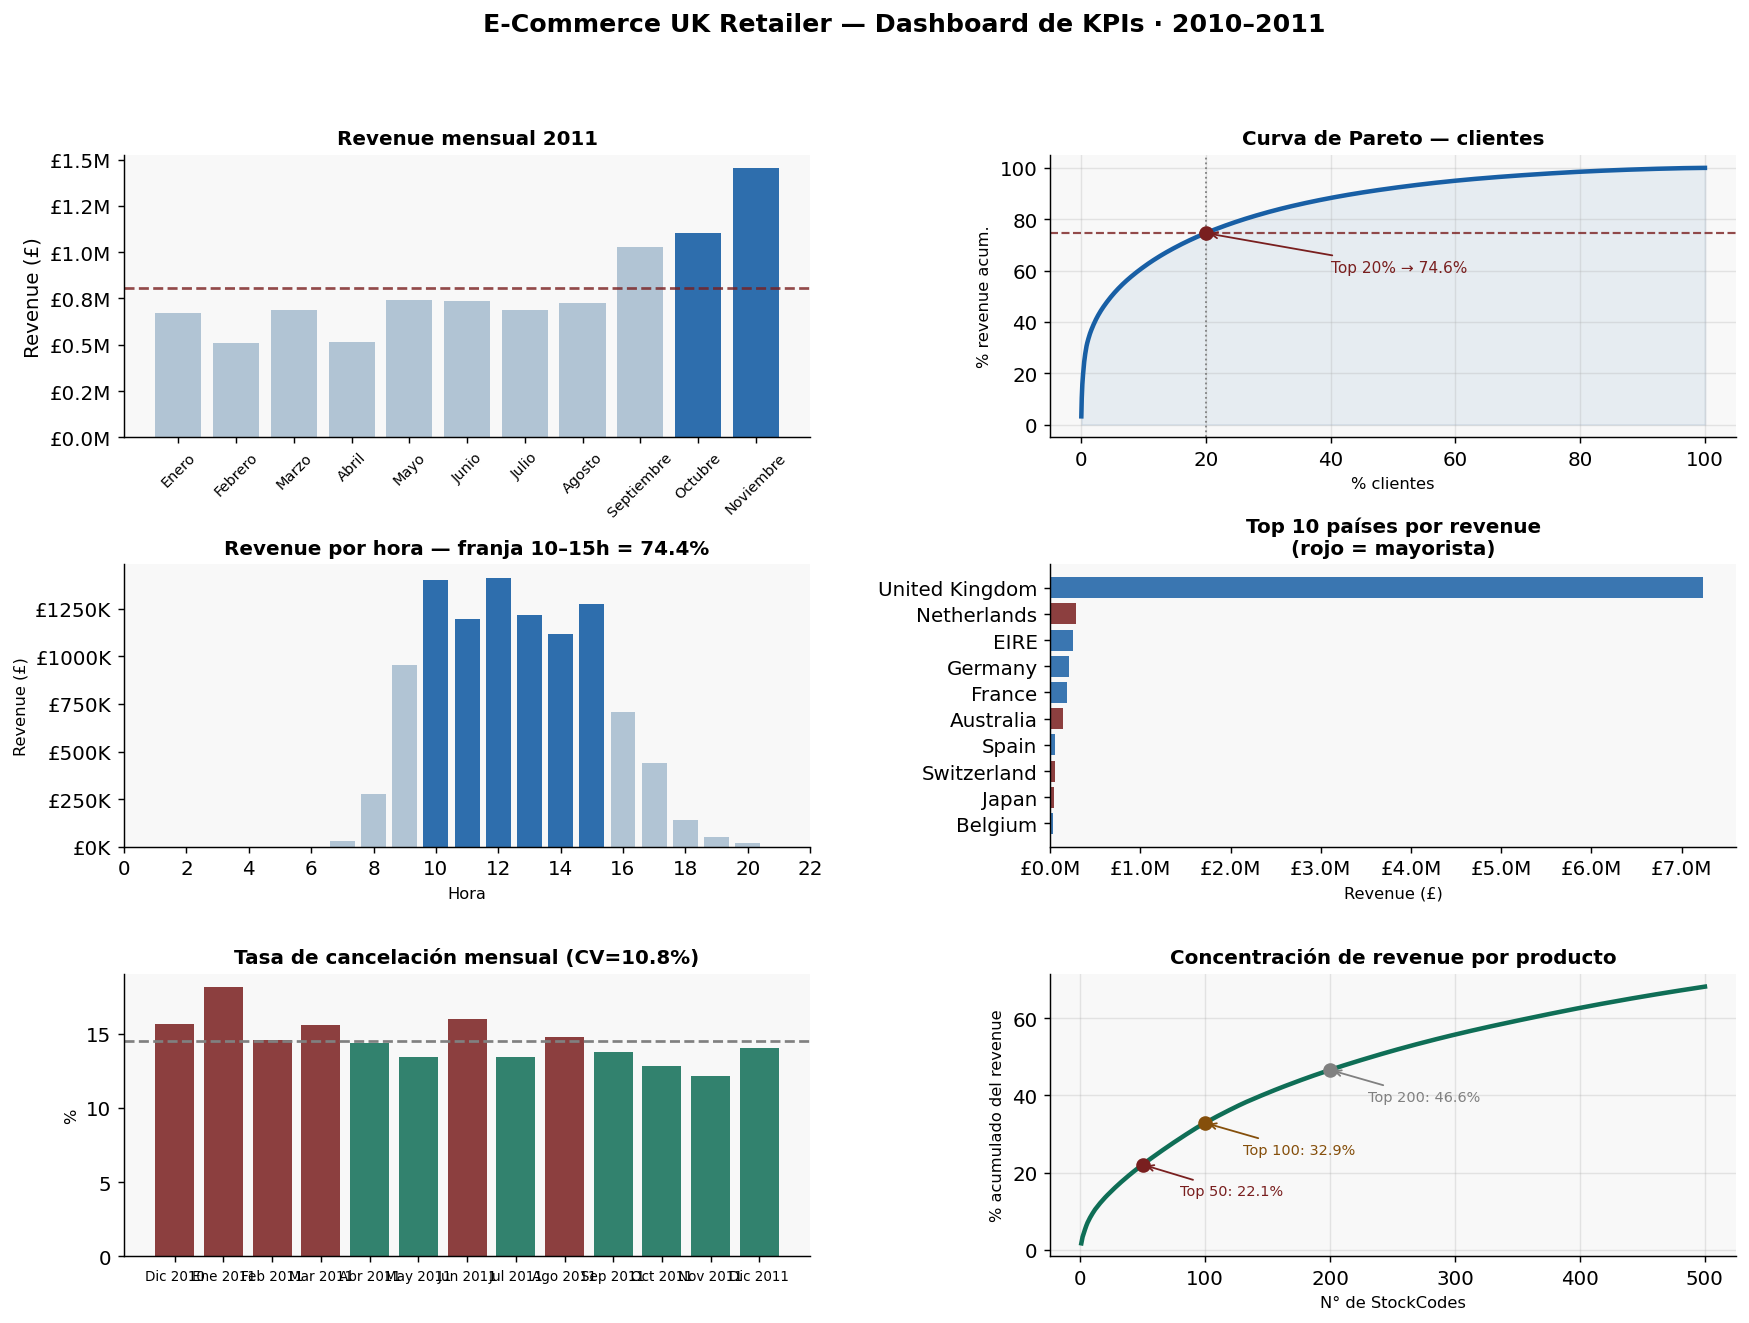

In [26]:
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])  # Revenue mensual
ax2 = fig.add_subplot(gs[0, 1])  # Pareto clientes
ax3 = fig.add_subplot(gs[1, 0])  # Franja horaria
ax4 = fig.add_subplot(gs[1, 1])  # Top 10 países revenue
ax5 = fig.add_subplot(gs[2, 0])  # Tasa cancelación
ax6 = fig.add_subplot(gs[2, 1])  # Concentración SC

rev_m2 = ventas_f[(ventas_f['Year']==2011) & (ventas_f['Month']<=11)].groupby(['Month','MonthNameES'])['Revenue'].sum().reset_index().sort_values('Month')
col_m = ['#185FA5' if m in [10,11] else '#AABFD0' for m in rev_m2['Month']]
ax1.bar(rev_m2['MonthNameES'], rev_m2['Revenue'], color=col_m, edgecolor='none', alpha=0.9)
ax1.axhline(rev_m2['Revenue'].mean(), color=C['rojo'], lw=1.5, ls='--', alpha=0.8)
ax1.set_title('Revenue mensual 2011', fontweight='bold', fontsize=11)
ax1.set_ylabel('Revenue (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))
ax1.tick_params(axis='x', rotation=45, labelsize=8)

ax2.plot(rev_x_cid['rank_pct'], rev_x_cid['rev_acum_pct'], color=C['azul'], lw=2.5)
ax2.fill_between(rev_x_cid['rank_pct'], rev_x_cid['rev_acum_pct'], alpha=0.08, color=C['azul'])
ax2.axhline(top20_pct, color=C['rojo'], lw=1.2, ls='--', alpha=0.8)
ax2.axvline(20, color='gray', lw=1, ls=':')
ax2.scatter([20], [top20_pct], color=C['rojo'], zorder=5, s=50)
ax2.annotate(f'Top 20% → {top20_pct:.1f}%', xy=(20, top20_pct),
             xytext=(40, top20_pct-15), fontsize=8.5, color=C['rojo'],
             arrowprops=dict(arrowstyle='->', color=C['rojo']))
ax2.set_title('Curva de Pareto — clientes', fontweight='bold', fontsize=11)
ax2.set_xlabel('% clientes', fontsize=9)
ax2.set_ylabel('% revenue acum.', fontsize=9)
ax2.grid(True, alpha=0.3)

rev_h2 = ventas_hora.groupby('Hour')['Revenue'].sum().sort_index()
col_h  = [C['azul'] if 10 <= h <= 15 else '#AABFD0' for h in rev_h2.index]
ax3.bar(rev_h2.index, rev_h2.values, color=col_h, edgecolor='none', alpha=0.9)
ax3.set_title(f'Revenue por hora — franja 10–15h = {pct_franja:.1f}%', fontweight='bold', fontsize=11)
ax3.set_xlabel('Hora', fontsize=9)
ax3.set_ylabel('Revenue (£)', fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{int(x/1e3)}K'))
ax3.set_xticks(range(0,24,2))

top10_paises_rev = rev_x_pais.sort_values('revenue', ascending=False).head(10)
col_geo = [C['rojo'] if m else C['azul'] for m in top10_paises_rev['IsMayorista']]
ax4.barh(top10_paises_rev['Country'][::-1], top10_paises_rev['revenue'][::-1],
         color=col_geo[::-1], edgecolor='none', alpha=0.85)
ax4.set_title('Top 10 países por revenue\n(rojo = mayorista)', fontweight='bold', fontsize=11)
ax4.set_xlabel('Revenue (£)', fontsize=9)
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))

col_c2 = [C['verde'] if v <= media_cancel else C['rojo'] for v in cancel_rate['tasa_pct']]
ax5.bar(range(len(cancel_rate)), cancel_rate['tasa_pct'],
        color=col_c2, edgecolor='none', alpha=0.85)
ax5.axhline(media_cancel, color='gray', lw=1.5, ls='--')
ax5.set_xticks(range(len(cancel_rate)))
ax5.set_xticklabels([f'{r["MonthNameES"][:3]} {int(r["Year"])}' for _, r in cancel_rate.iterrows()], fontsize=7.5)
ax5.set_title(f'Tasa de cancelación mensual (CV={cv_cancel:.1f}%)', fontweight='bold', fontsize=11)
ax5.set_ylabel('%', fontsize=9)

ax6.plot(rev_x_sc['rank'].head(500), rev_x_sc['rev_acum_pct'].head(500),
         color=C['verde'], lw=2.5)
for n, col in [(50, C['rojo']), (100, C['ocre']), (200, 'gray')]:
    pct_n2 = rev_x_sc.head(n)['rev_acum_pct'].iloc[-1]
    ax6.scatter([n], [pct_n2], color=col, s=50, zorder=5)
    ax6.annotate(f'Top {n}: {pct_n2:.1f}%', xy=(n, pct_n2),
                 xytext=(n+30, pct_n2-8), fontsize=8, color=col,
                 arrowprops=dict(arrowstyle='->', color=col))
ax6.set_title('Concentración de revenue por producto', fontweight='bold', fontsize=11)
ax6.set_xlabel('N° de StockCodes', fontsize=9)
ax6.set_ylabel('% acumulado del revenue', fontsize=9)
ax6.grid(True, alpha=0.3)

fig.suptitle('E-Commerce UK Retailer — Dashboard de KPIs · 2010–2011',
             fontsize=14, fontweight='bold', y=0.98)

plt.savefig('../assets/05_dashboard_kpis.png', dpi=130, bbox_inches='tight')
plt.show()

---
### Síntesis del análisis

**Los 5 hallazgos más importantes del proyecto:**

1. **El negocio tiene una ventana operativa de 6 horas** (10–15h = 74.4% del revenue). Todo lo que ocurre fuera de esa franja es marginal.

2. **El 20% de los clientes genera el 74.6% del revenue** — concentración extrema que justifica una estrategia de retención diferenciada para el top tier.

3. **El segmento Guest gasta 1.34× más por factura que el identificado** — un segmento aparentemente anónimo que en realidad se comporta como mayorista. Oportunidad de captación.

4. **6 países son distribuidores mayoristas** con tickets 3.2–7.0× superiores a UK, con ≤9 clientes cada uno. Son el 9.6% de la base de clientes pero generan el 17.1% del revenue.

5. **La tasa de cancelación es estructuralmente estable (CV=10.8%)** y *desciende* en el mes de mayor demanda — lo que permite proyectar el revenue neto de noviembre con alta confianza.

**Próximo paso:** dashboard interactivo en Power BI o Looker Studio sobre el modelo relacional construido.